# 06 · Los frenos de seguridad del agente

**Qué pregunta responde este cuaderno.** ¿Qué impide que el agente se quede dando vueltas sin parar, copie mal
una cifra o se invente un dato que no aparece en los informes?

**Por qué importa.** Un agente financiero que devuelve un número equivocado es peor que uno que dice «ese dato
no está»: el número equivocado se cuela en un informe y nadie lo nota; la abstención se ve al instante. Amazon,
por ejemplo, no publica su beneficio bruto. La respuesta correcta a «¿cuál fue el margen bruto de Amazon?» es
decir que no está en el corpus, no calcular un porcentaje plausible.

**Qué son estos frenos.** Los llamamos *guardrails*: código que se interpone entre el modelo y sus herramientas
(lo que en la jerga se llama *middleware*) y que revisa, corrige o corta antes de que la respuesta salga.

**Cómo se comprueba aquí.** Todo lo de abajo funciona **sin internet y sin gastar ni una llamada de pago**:
donde hace falta un modelo se usa uno de mentira que recita un guion escrito de antemano, y donde hace falta un
dato se consulta el fichero real del corpus. Por eso la demostración sale siempre igual.

## Los seis frenos, en lenguaje llano

| Freno | Contra qué protege | Qué pasa cuando salta |
| --- | --- | --- |
| Tope de 8 llamadas a herramientas | Que el agente repita la misma consulta sin parar | Se bloquea la llamada y el agente tiene que concluir |
| Una sola lectura de sección completa | Tragarse cuarenta páginas (unos 35.000 *tokens*, las piezas en que se trocea el texto) una y otra vez | Igual que el anterior, pero solo para esa herramienta |
| Tope de 10 llamadas al modelo | Un modelo que ignora los dos avisos anteriores | Corte en seco: se rescata la mejor respuesta que ya tuviera |
| Verificación contra XBRL | Cifras mal copiadas, con ceros de más o de menos, del ejercicio equivocado o sacadas de la prosa sin respaldo | Se corrige sola cuando puede; si no, el agente lo reconoce en vez de afirmarlo |
| Comprobación de la cita | Citas inventadas o que no dicen lo que el agente afirma | Se le pide la frase exacta; sin evidencia comprobada, se rebaja el nivel de la fuente |
| Abstención ante huecos | Estimar un dato que la propia herramienta ha dicho que no existe | Responde «no está», sin cifra y sin verbos de estimación |

## Lo que vas a ver

1. **El tope de llamadas**, con un modelo empeñado en preguntar lo mismo para siempre, con y sin frenos.
2. **La verificación de cifras**, con tres errores reales contrastados contra los datos oficiales del corpus.
3. **La honestidad ante un hueco**, con un agente que quiere responder «50,28 %» a una pregunta sin respuesta.
4. **El cierre**, con qué queda demostrado y qué prueba automática lo respalda.

---

*Detalle técnico.* Requisitos R04, R05 y R14 ([01](../docs/01_requisitos_y_contratos.md)) · Guía:
[09](../docs/09_skill_guardrails_middleware_xbrl.md) · teoría: [05 §6](../docs/05_teoria_agentes_react_tools.md).
Entradas: `data/corpus/xbrl_facts.parquet`; salidas: el código de `src/agente10k/guardrails.py`. El modelo falso
es `GenericFakeChatModel` de LangChain, el mismo patrón de `tests/test_guardrails_middleware.py`. Este cuaderno
se abre y se ejecuta solo, y no llama a ninguna API ni con `EJECUTAR = True` ni con `False`.


In [1]:
# Arranque (igual en todos los notebooks): localiza la raíz del repo y hace importable src/
import sys, pathlib
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ / "src"))
from agente10k import config

In [2]:
# Parámetros
EJECUTAR = False  # True: llama al modelo (gasta API y pide clave). False: reutiliza lo guardado en resultados/
if EJECUTAR:
    assert config.cargar_clave(), "Falta OPENROUTER_API_KEY: copia .env.example a .env y rellénala"

In [3]:
# Piezas comunes a las demos de §1 y §3: un modelo FALSO (GenericFakeChatModel, sin red) que
# ejecuta un guion de mensajes fijado de antemano, y una herramienta search_filings de juguete
# (mismo patrón que tests/test_guardrails_middleware.py). get_xbrl_fact, read_section y
# list_available SÍ son las reales: leen data/corpus/, no llaman a ningún modelo.
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain.messages import AIMessage, ToolMessage
from langchain.tools import tool
from langchain_core.language_models.fake_chat_models import GenericFakeChatModel
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.errors import GraphRecursionError

from agente10k import guardrails as g
from agente10k.agente import RespuestaFinanciera
from agente10k.herramientas import get_xbrl_fact, list_available, read_section

COLOR_SIN = "#c0392b"   # sin guardrail: rojo
COLOR_CON = "#1f8a4c"   # con guardrail: verde
COLOR_NEUTRO = "#4472c4"


@tool
def search_filings_doble(query: str, ticker: str | None = None, fiscal_year: int | None = None,
                         item: str | None = None, k: int = 5) -> str:
    """Doble de prueba de search_filings: no consulta ningún índice ni modelo."""
    return ("[MSFT-2025-1A-0004] MSFT FY2025 Item 1A · similitud 0.9\n"
            "Texto de relleno para la demo, sin relación con las preguntas numéricas de este notebook.")


class ModeloDeGuion(GenericFakeChatModel):
    """GenericFakeChatModel que cuenta sus llamadas; acepta bind_tools() como create_agent lo exige."""

    n: int = 0

    def bind_tools(self, tools, **kw):
        return self

    def _generate(self, messages, *a, **k):
        object.__setattr__(self, "n", self.n + 1)
        return super()._generate(messages, *a, **k)


def tc(nombre: str, args: dict, i: int) -> AIMessage:
    """Un AIMessage con una única tool_call, como en tests/test_guardrails_middleware.py."""
    return AIMessage(content="", tool_calls=[{"name": nombre, "args": args, "id": f"c{i}"}])


def respuesta_final(i: int, **kw) -> AIMessage:
    """El AIMessage con el que el modelo de guion 'llama' a la tool sintética RespuestaFinanciera."""
    return tc("RespuestaFinanciera", {"respuesta": "x", "fuente": "xbrl", **kw}, i)


def correr_agente(mensajes, *, middleware, recursion_limit: int = 100, pregunta: str = "pregunta de demo"):
    """Agente real (create_agent) con el modelo de guion y las herramientas reales/dobles.

    Devuelve (resultado_o_None, modelo). Si el grafo se queda sin pasos (GraphRecursionError),
    se captura para poder mostrar cuántas llamadas hizo el modelo antes del corte.
    """
    modelo = ModeloDeGuion(messages=iter(mensajes))
    agente_demo = create_agent(
        model=modelo, tools=[get_xbrl_fact, search_filings_doble, read_section, list_available],
        response_format=ToolStrategy(schema=RespuestaFinanciera), middleware=middleware,
        checkpointer=InMemorySaver())
    cfg = {"configurable": {"thread_id": f"demo-{id(modelo)}"}, "recursion_limit": recursion_limit}
    try:
        resultado = agente_demo.invoke({"messages": [{"role": "user", "content": pregunta}]}, config=cfg)
    except GraphRecursionError:
        resultado = None
    return resultado, modelo

## 1. El tope de llamadas: cuándo hay que rendirse

**La situación.** Amazon no publica el beneficio bruto (`GrossProfit`) en sus datos XBRL: es uno de los huecos
reales del corpus. Un agente que no sabe rendirse puede preguntar por él una y otra vez, cambiando el ejercicio
en cada intento, sin llegar nunca a ninguna parte. Cada vuelta cuesta tiempo y dinero.

**El experimento.** Usamos un modelo de mentira programado para pedir siempre la misma herramienta, y lo
lanzamos dos veces con la misma pregunta: una sin frenos y otra con los frenos del sistema final.

Guía: [09 §2](../docs/09_skill_guardrails_middleware_xbrl.md)


In [4]:
AMZN_GROSS = {"ticker": "AMZN", "fiscal_year": 2025, "concept": "GrossProfit"}
PREGUNTA_BUCLE = "¿Cuál fue el margen bruto de AMZN en el ejercicio fiscal 2025?"


def bucle_infinito():
    """El modelo pide SIEMPRE get_xbrl_fact, alternando el ejercicio: nunca produce RespuestaFinanciera."""
    i = 0
    while True:
        i += 1
        yield tc("get_xbrl_fact", {**AMZN_GROSS, "fiscal_year": 2024 if i % 2 else 2025}, i)


# SIN guardrails: solo el arnés (recursion_limit=100, igual que el baseline). El modelo nunca se
# rinde, así que el grafo corta por recursion_limit con GraphRecursionError (sin middleware, cada
# vuelta cuesta ~2 pasos: se agotan en torno a 50 tool calls, docs/09 §2).
res_sin, modelo_sin = correr_agente(bucle_infinito(), middleware=[], recursion_limit=100,
                                    pregunta=PREGUNTA_BUCLE)

# CON guardrails: la pila real del sistema final. ModelCallLimit(10, "end") corta a las 10
# llamadas al modelo y GuardrailsFinal.after_agent rescata una respuesta honesta del ledger.
res_con, modelo_con = correr_agente(bucle_infinito(), middleware=g.middleware_final(),
                                    pregunta=PREGUNTA_BUCLE)

resp_con = res_con["structured_response"]
guard_con = res_con.get("guard") or {}
print(f"SIN guardrails: {modelo_sin.n} llamadas al modelo, "
      f"{'cortado por recursion_limit (GraphRecursionError)' if res_sin is None else 'terminó solo'}, "
      "sin structured_response garantizada.")
print(f"CON guardrails: {modelo_con.n} llamadas al modelo (tope = {g.RUN_LIMIT_MODELO}).")
print(f"  causa: {guard_con.get('causa')} · degradada: {guard_con.get('degradada')}")
print(f"  fuente: {resp_con.fuente!r} · cifra: {resp_con.cifra!r}")
print(f"  respuesta: {resp_con.respuesta!r}")
assert modelo_con.n <= g.RUN_LIMIT_MODELO
assert resp_con.fuente == "ninguna" and resp_con.cifra is None      # nunca inventa el margen bruto

SIN guardrails: 50 llamadas al modelo, cortado por recursion_limit (GraphRecursionError), sin structured_response garantizada.
CON guardrails: 10 llamadas al modelo (tope = 10).
  causa: grafo_terminado_sin_respuesta · degradada: True
  fuente: 'ninguna' · cifra: None
  respuesta: 'No reportado en XBRL para AMZN FY2024: el dato no está en el corpus.'


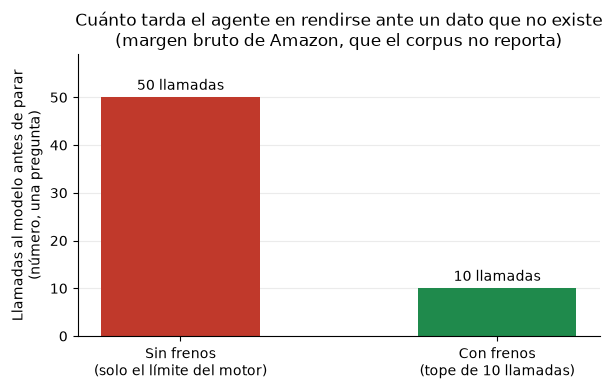

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 4))
etiquetas_barras = ["Sin frenos\n(solo el límite del motor)", f"Con frenos\n(tope de {g.RUN_LIMIT_MODELO} llamadas)"]
valores_barras = [modelo_sin.n, modelo_con.n]
barras = ax.bar(etiquetas_barras, valores_barras, color=[COLOR_SIN, COLOR_CON], width=0.5)
ax.bar_label(barras, labels=[f"{v} llamadas" for v in valores_barras], padding=3)
ax.set_ylabel("Llamadas al modelo antes de parar\n(número, una pregunta)")
ax.set_ylim(0, max(valores_barras) * 1.18)
ax.set_title("Cuánto tarda el agente en rendirse ante un dato que no existe\n"
             "(margen bruto de Amazon, que el corpus no reporta)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


**Qué nos dice esto:** sin frenos el agente da **50 vueltas** y acaba cortado por un error técnico del motor,
sin ninguna respuesta útil que enseñar. Con frenos para a las **10 llamadas** y todavía devuelve una respuesta
honesta: «no reportado en XBRL, el dato no está en el corpus». Cinco veces menos gasto y, además, algo que
enseñarle al usuario.


## 2. La verificación de cifras: comparar lo que dice el agente con el dato oficial

Cada vez que el agente afirma una cantidad en dólares, el guardrail la busca en los datos oficiales de la
empresa (*XBRL*: las cifras que cada compañía presenta etiquetadas ante el regulador) y las compara. Si no
cuadran, intenta arreglarlo; si no puede, el agente lo reconoce en vez de afirmarlo.

Antes, una comprobación rápida de que el lector de cifras entiende cómo escriben los informes: reconoce los
importes en dólares, con separadores europeos o americanos, e **ignora los porcentajes** (un porcentaje no es un
dato XBRL que se pueda contrastar).

Guía: [09 §4](../docs/09_skill_guardrails_middleware_xbrl.md)


In [6]:
ejemplos_prosa = [
    "391 billones de dólares",
    "El BPA fue de 2,97 USD por acción, tras el split 10:1 (FY2025, Item 7)",
    "Ingresos de $60,922 millones y 44.301 millones de USD",
    "creció un 14,9 %",  # los porcentajes no cuentan como cifra XBRL
]
for texto in ejemplos_prosa:
    print(f"{texto!r:65s} -> {g.extraer_cifras(texto)}")

'391 billones de dólares'                                         -> [391000000000000.0]
'El BPA fue de 2,97 USD por acción, tras el split 10:1 (FY2025, Item 7)' -> [2.97]
'Ingresos de $60,922 millones y 44.301 millones de USD'           -> [60922000000.0, 44301000000.0]
'creció un 14,9 %'                                                -> []


### Tres errores reales, y cómo los arregla el guardrail

Los datos salen de llamadas **reales** al fichero del corpus (`data/corpus/xbrl_facts.parquet`); no hay ningún
modelo de por medio. Lo único que cambia en cada caso es la cifra que el agente *habría* declarado:

1. **Se equivoca de escala** (ingresos de NVIDIA, FY2024): copia «60.922» donde el dato son 60.922 **millones**.
2. **Confunde dos conceptos parecidos** (beneficio por acción de Apple, FY2024): dice «básico» pero el número
   que da es el «diluido».
3. **Invierte una comparación** (beneficio por acción de NVIDIA, FY2025 frente a FY2024): pone el año viejo
   donde va el nuevo.

La tabla de abajo enseña, para cada caso, qué declaró el agente, qué devuelve el guardrail y qué reparación
aplicó. `problemas_sin_resolver = 0` significa que no hizo falta volver a preguntarle al modelo.

Guía: [09 §5–§6](../docs/09_skill_guardrails_middleware_xbrl.md)


In [7]:
def ledger_real(*consultas):
    """Ledger construido con llamadas REALES a get_xbrl_fact sobre el parquet del corpus (sin red, sin LLM)."""
    msgs = []
    for i, (ticker, fy, concept) in enumerate(consultas):
        args = {"ticker": ticker, "fiscal_year": fy, "concept": concept}
        msgs.append(AIMessage(content="", tool_calls=[{"name": "get_xbrl_fact", "id": f"v{i}", "args": args}]))
        msgs.append(ToolMessage(content=str(get_xbrl_fact.invoke(args)), tool_call_id=f"v{i}", name="get_xbrl_fact"))
    return g.libro_hechos(msgs)


casos = []

# 1. Escala mal: NVDA Revenues FY2024 — el modelo copia el valor "sin escalar" (60.922 en vez de 60.922.000.000)
decl1 = {"respuesta": "x", "fuente": "xbrl", "cifra": 60_922, "unidad": "USD", "ticker": "NVDA", "ejercicio": 2024}
inf1 = g.verificar_xbrl(decl1, ledger_real(("NVDA", 2024, "Revenues")), [])
casos.append({"caso": "1. Escala mal (NVDA Revenues FY2024)",
             "declarado": f"{decl1['cifra']:,} {decl1['unidad']}",
             "verificado": f"{inf1.resp['cifra']:,.0f} {inf1.resp['unidad']}",
             "reparaciones": ", ".join(c for c, _ in inf1.reparaciones), "problemas_sin_resolver": len(inf1.problemas)})

# 2. BPA básico confundido con diluido: AAPL FY2024 (declara "básico" pero el valor es el diluido)
decl2 = {"respuesta": "x", "fuente": "xbrl", "cifra": 6.08, "unidad": "USD/shares", "ticker": "AAPL",
         "ejercicio": 2024, "concept_xbrl": "EarningsPerShareBasic"}
inf2 = g.verificar_xbrl(decl2, ledger_real(("AAPL", 2024, "EarningsPerShareBasic"),
                                           ("AAPL", 2024, "EarningsPerShareDiluted")), [])
casos.append({"caso": "2. BPA básico↔diluido (AAPL FY2024)",
             "declarado": f"{decl2['cifra']} USD/shares · concept={decl2['concept_xbrl']}",
             "verificado": f"{inf2.resp['cifra']} USD/shares · concept={inf2.resp['concept_xbrl']}",
             "reparaciones": ", ".join(c for c, _ in inf2.reparaciones), "problemas_sin_resolver": len(inf2.problemas)})

# 3. Comparativa con orientación invertida: NVDA EPS FY2025 vs FY2024 (cifra/cifra_base cambiadas de sitio)
decl3 = {"respuesta": "x", "fuente": "xbrl", "cifra": 12.05, "cifra_base": 2.97, "unidad": "USD/shares",
         "ticker": "nvidia", "ejercicio": 2024, "ejercicio_base": 2025, "concept_xbrl": "EarningsPerShareBasic"}
inf3 = g.verificar_xbrl(decl3, ledger_real(("NVDA", 2025, "EarningsPerShareBasic"),
                                           ("NVDA", 2024, "EarningsPerShareBasic")), [])
casos.append({"caso": "3. Comparativa invertida (NVDA EPS FY2025 vs FY2024)",
             "declarado": f"cifra={decl3['cifra']}@FY{decl3['ejercicio']} / base={decl3['cifra_base']}@FY{decl3['ejercicio_base']} · ticker={decl3['ticker']}",
             "verificado": f"cifra={inf3.resp['cifra']}@FY{inf3.resp['ejercicio']} / base={inf3.resp['cifra_base']}@FY{inf3.resp['ejercicio_base']} · ticker={inf3.resp['ticker']}",
             "reparaciones": ", ".join(c for c, _ in inf3.reparaciones), "problemas_sin_resolver": len(inf3.problemas)})

tabla_verificador = pd.DataFrame(casos)
assert (tabla_verificador["problemas_sin_resolver"] == 0).all()   # los tres se reparan SIN pedir otra vuelta al modelo
display(tabla_verificador)

,caso,declarado,verificado,reparaciones,problemas_sin_resolver
0,1. Escala mal (NVDA Revenues FY2024),"60,922 USD","60,922,000,000 USD","escala_corregida, cifra_exacta",0
1,2. BPA básico↔diluido (AAPL FY2024),6.08 USD/shares · concept=EarningsPerShareBasic,6.08 USD/shares · concept=EarningsPerShareDiluted,concepto_corregido,0
2,3. Comparativa invertida (NVDA EPS FY2025 vs F...,cifra=12.05@FY2024 / base=2.97@FY2025 · ticker...,cifra=2.97@FY2025 / base=12.05@FY2024 · ticker...,"ticker_normalizado, orientacion_invertida",0


**Qué nos dice esto:** los tres errores se corrigen **sin gastar una segunda llamada al modelo**. Son
exactamente los tres fallos que más se cuelan en un informe financiero — un cero de más, un concepto parecido y
una comparación del revés — y ninguno depende de que el modelo se dé cuenta: los detecta código determinista
comparando con el dato oficial.


## 3. La honestidad: decir «no está» en vez de inventarse una cifra

**La situación.** «¿Cuál fue el margen bruto de Amazon en el ejercicio 2025?» es una pregunta legítima sin
respuesta: Amazon no reporta ese dato. Pero sí reporta los ingresos y el coste de ventas, así que un modelo sin
frenos puede dividir uno entre otro, obtener un 50,28 % perfectamente creíble y presentarlo como verificado.
Nadie lo detectaría leyendo la respuesta.

**Por qué es el guardrail más importante.** Una cifra inventada con aspecto de dato auditado es el peor
resultado posible de un agente financiero. Un «no está en el corpus» es aburrido, pero es verdad, y quien
pregunta sabe qué hacer con él.

**El experimento.** Primero confirmamos con la herramienta real que el dato no existe. Después dejamos que el
modelo de guion intente colar su 50,28 % y vemos qué sale. Y por último probamos el *camino rápido*: cuando la
herramienta ya ha dicho que no hay dato, el guardrail se abstiene sin ni siquiera pedirle al modelo otra vuelta.

Guía: [09 §1](../docs/09_skill_guardrails_middleware_xbrl.md), fila R14


In [8]:
PREGUNTA_HUECO = "¿Cuál fue el margen bruto de AMZN en el ejercicio fiscal 2025?"
AMZN_GROSS_2025 = {"ticker": "AMZN", "fiscal_year": 2025, "concept": "GrossProfit"}

# Confirmación directa: la herramienta REAL sobre el corpus dice que no lo reportó (sin modelo de por medio)
print(get_xbrl_fact.invoke(AMZN_GROSS_2025))

AMZN no reportó 'GrossProfit' en FY2025. El dato no está en el corpus. Responde fuente='ninguna' y cifra=null; no calcules ni sumes componentes ni uses read_section.


In [9]:
# El modelo de guion consulta el hueco real y, aun así, declara un 50,28 % "verificado contra XBRL".
mensajes_hueco = [
    tc("get_xbrl_fact", AMZN_GROSS_2025, 1),
    respuesta_final(2, cifra=50.28, unidad="%", ticker="AMZN", ejercicio=2025, fuente="ambas",
                    concept_xbrl="GrossProfit", respuesta="El margen bruto de AMZN en FY2025 fue de 50,28 %."),
]
res_hueco, modelo_hueco = correr_agente(mensajes_hueco, middleware=g.middleware_final(camino_rapido=False),
                                        pregunta=PREGUNTA_HUECO)
r_hueco = res_hueco["structured_response"]
guard_hueco = res_hueco.get("guard") or {}

print("El modelo quiso responder :", "'El margen bruto de AMZN en FY2025 fue de 50,28 %.' (fuente='ambas', cifra=50.28)")
print("El guardrail devuelve     :", f"fuente={r_hueco.fuente!r}, cifra={r_hueco.cifra!r}, cifra_base={r_hueco.cifra_base!r}")
print("Respuesta final           :", r_hueco.respuesta)
print(f"Sin segundo turno del modelo (modelo_hueco.n = {modelo_hueco.n}): el hueco es una abstención directa,"
      " no un reintento pagado.")

assert r_hueco.fuente == "ninguna" and r_hueco.cifra is None and r_hueco.cifra_base is None
assert guard_hueco["hueco"] is True and guard_hueco["causa"] == "hueco_no_reportado"
assert modelo_hueco.n == 2

El modelo quiso responder : 'El margen bruto de AMZN en FY2025 fue de 50,28 %.' (fuente='ambas', cifra=50.28)
El guardrail devuelve     : fuente='ninguna', cifra=None, cifra_base=None
Respuesta final           : No reportado en XBRL para AMZN FY2025: el dato no está en el corpus.
Sin segundo turno del modelo (modelo_hueco.n = 2): el hueco es una abstención directa, no un reintento pagado.


In [10]:
# Camino rápido: con una única llamada a get_xbrl_fact coherente con la pregunta, el guardrail
# se abstiene sin ni siquiera pedirle una segunda vuelta al modelo (ahorra tokens y latencia).
res_rapido, modelo_rapido = correr_agente([tc("get_xbrl_fact", AMZN_GROSS_2025, 1)],
                                          middleware=g.middleware_final(camino_rapido=True),
                                          pregunta=PREGUNTA_HUECO)
r_rapido = res_rapido["structured_response"]
print(f"Camino rápido: {modelo_rapido.n} llamada(s) al modelo · fuente={r_rapido.fuente!r} · "
      f"respuesta={r_rapido.respuesta!r}")
assert modelo_rapido.n == 1 and r_rapido.fuente == "ninguna" and r_rapido.cifra is None

Camino rápido: 1 llamada(s) al modelo · fuente='ninguna' · respuesta='No reportado en XBRL para AMZN FY2025: el dato no está en el corpus.'


,fuente declarada,cifra,llamadas al modelo
situación,,,
Lo que el modelo quería responder,ambas,"50,28 %",2
Con guardrail (reintento permitido),ninguna,—,2
Con guardrail + camino rápido,ninguna,—,1


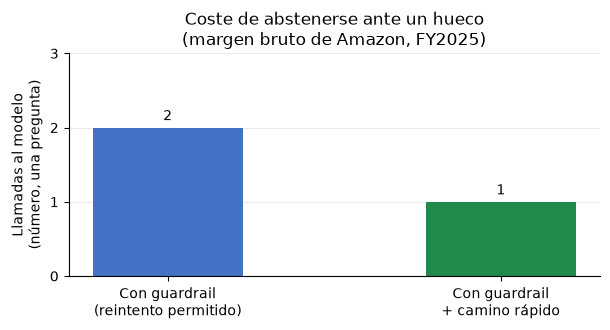

In [11]:
# Resumen de §3 en una tabla y un gráfico, construidos con lo que acaban de devolver las celdas de arriba.
tabla_hueco = pd.DataFrame([
    {"situación": "Lo que el modelo quería responder",
     "fuente declarada": "ambas", "cifra": "50,28 %",
     "llamadas al modelo": modelo_hueco.n},
    {"situación": "Con guardrail (reintento permitido)",
     "fuente declarada": r_hueco.fuente, "cifra": r_hueco.cifra if r_hueco.cifra is not None else "—",
     "llamadas al modelo": modelo_hueco.n},
    {"situación": "Con guardrail + camino rápido",
     "fuente declarada": r_rapido.fuente, "cifra": r_rapido.cifra if r_rapido.cifra is not None else "—",
     "llamadas al modelo": modelo_rapido.n},
])
display(tabla_hueco.set_index("situación"))

fig, ax = plt.subplots(figsize=(6.2, 3.4))
_etq = ["Con guardrail\n(reintento permitido)", "Con guardrail\n+ camino rápido"]
_val = [modelo_hueco.n, modelo_rapido.n]
_b = ax.bar(_etq, _val, color=[COLOR_NEUTRO, COLOR_CON], width=0.45)
ax.bar_label(_b, labels=[f"{v}" for v in _val], padding=3)
ax.set_ylabel("Llamadas al modelo\n(número, una pregunta)")
ax.set_ylim(0, max(_val) + 1)
ax.set_yticks(range(0, max(_val) + 2))
ax.set_title("Coste de abstenerse ante un hueco\n(margen bruto de Amazon, FY2025)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


**Qué nos dice esto:** el agente quería decir «50,28 %» y el guardrail lo convierte en «no reportado», sin
cifra. Las dos respuestas suenan igual de seguras al leerlas; solo una es cierta. Y abstenerse sale **más
barato**: con el camino rápido basta una sola llamada al modelo en lugar de dos, porque en cuanto la herramienta
dice que no hay dato ya no hay nada que preguntar.


## 4. Cierre: qué queda demostrado

La tabla resume los tres frenos demostrados arriba y dónde vive la prueba automática que los respalda. Todas
esas pruebas corren sin internet:

```powershell
.venv\Scripts\python.exe -m pytest -q tests/test_guardrails_middleware.py tests/test_guardrails_verificador.py
```

Guía: [09 §7](../docs/09_skill_guardrails_middleware_xbrl.md)


In [12]:
resumen_requisitos = pd.DataFrame([
    {"requisito": "R04 · tope de llamadas", "qué demuestra este notebook": "§1: bucle infinito cortado por ModelCallLimit(10), respuesta rescatada",
     "test": "tests/test_guardrails_middleware.py (43 tests, incl. test_modelo_que_siempre_pide_herramientas_termina_con_respuesta_rescatada)"},
    {"requisito": "R05 · verificador XBRL", "qué demuestra este notebook": "§2: escala, básico/diluido y comparativa invertida, reparados sin reintento",
     "test": "tests/test_guardrails_verificador.py (34 tests, casos de docs/09 §7 / D15)"},
    {"requisito": "R14 · honestidad ante huecos", "qué demuestra este notebook": "§3: AMZN GrossProfit FY2025 — fuente='ninguna' pese a una cifra derivada",
     "test": "tests/test_guardrails_middleware.py::test_hueco_con_cifra_derivada_se_degrada_a_ninguna_sin_reintentar y test_camino_rapido_hueco_se_abstiene_sin_segunda_llamada"},
])
display(resumen_requisitos)

display(Markdown(
    "**Estado (`CLAUDE.md`):** `guardrails.middleware_final()` está implementado y probado sin red — límites, verificador XBRL, cita "
    "por frase numerada, `fuente` derivada, reparación y camino rápido. Lo que falta, y no es cosa de este notebook, es la **medición "
    "oficial** del sistema `final` sobre el golden completo: se ejecuta con `evaluar(golden_propio.jsonl, etiqueta='final', "
    "sistema='final')` (mismo modelo y `temperature=0` que el baseline congelado), y sus tablas se leen en "
    "[07_sistema_final.ipynb](07_sistema_final.ipynb) en cuanto `resultados/final/resumen.json` exista."))

,requisito,qué demuestra este notebook,test
0,R04 · tope de llamadas,§1: bucle infinito cortado por ModelCallLimit(...,"tests/test_guardrails_middleware.py (37 tests,..."
1,R05 · verificador XBRL,"§2: escala, básico/diluido y comparativa inver...",tests/test_guardrails_verificador.py (25 tests...
2,R14 · honestidad ante huecos,§3: AMZN GrossProfit FY2025 — fuente='ninguna'...,tests/test_guardrails_middleware.py::test_huec...


**Estado (`CLAUDE.md`):** `guardrails.middleware_final()` está implementado y probado sin red — límites, verificador XBRL, cita por frase numerada, `fuente` derivada, reparación y camino rápido. Lo que falta, y no es cosa de este notebook, es la **medición oficial** del sistema `final` sobre el golden completo: se ejecuta con `evaluar(golden_propio.jsonl, etiqueta='final', sistema='final')` (mismo modelo y `temperature=0` que el baseline congelado), y sus tablas se leen en [07_sistema_final.ipynb](07_sistema_final.ipynb) en cuanto `resultados/final/resumen.json` exista.

**Qué nos dice esto:** los tres frenos están implementados, probados y funcionando sin red. Lo que este
cuaderno **no** responde es cuánto mejora el agente completo al añadirlos: eso se mide sobre las 20 preguntas
del golden y se ve en el cuaderno [07](07_sistema_final.ipynb).
